# Team 14 Time Series Analysis

#### Group Members: Ernest Ceballos, Júlia Galimany, Oriol Galimany, Iván Pérez, Nerea Salvador

## Task 1. Data loading and exploration + Task 2. Preprocessing & Feature Engineering

**Libraries**

In [87]:
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import chain

**Load 14 selected records**

In [2]:
id_ls = [100, 101, 105, 106, 108, 109, 111, 112, 115, 117, 119, 201, 213, 219]

In [3]:
raw_signals = []
raw_annots = []

for rec_id in id_ls:
    raw_signals.append(wfdb.rdrecord(str(rec_id), pn_dir='mitdb'))
    raw_annots.append(wfdb.rdann(str(rec_id), 'atr', pn_dir='mitdb'))

For 2 random records, we will plot a 5-second segment of the raw ECG signal

In [94]:
fs = 360 # Hz
time_5sec=np.arange(fs * 5)/fs

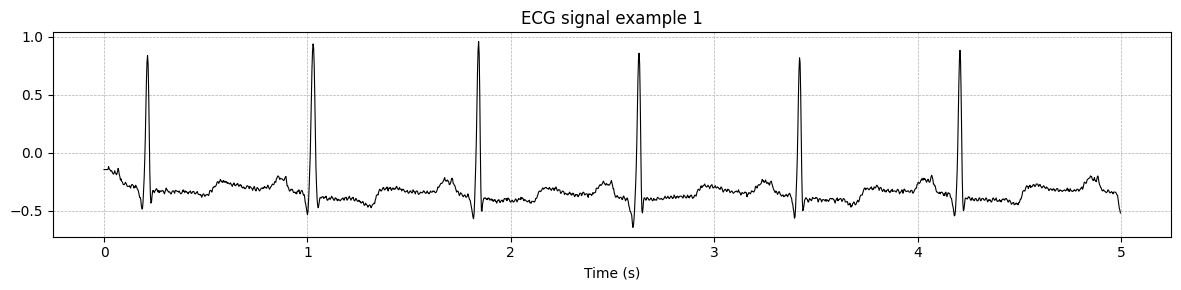

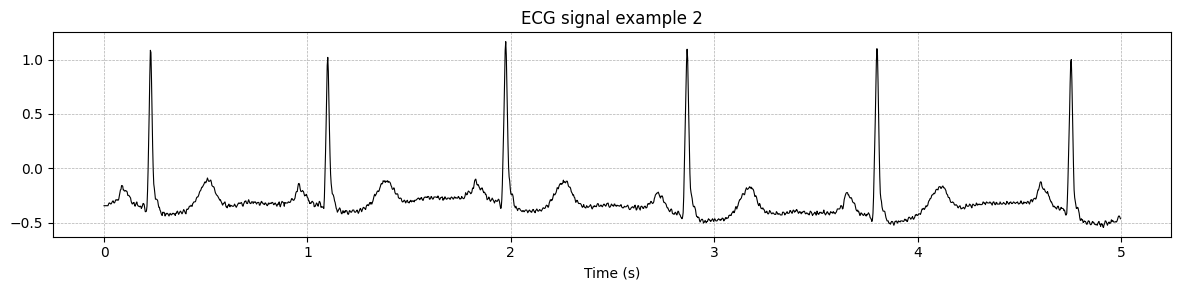

In [95]:
plt.figure(figsize=(12, 3))
plt.plot(time_5sec, raw_signals[0].p_signal[:len(time_5sec), 0], color='k', linewidth=0.8)
plt.xlabel('Time (s)')
plt.title('ECG signal example 1')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(time_5sec, raw_signals[1].p_signal[:len(time_5sec), 0], color='k', linewidth=0.8)
plt.xlabel('Time (s)')
plt.title('ECG signal example 2')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

The following dictionary is used to map the annotated peaks into the categories N, S and V, following the AAMI EC57 standard. The symbols that are not included will be discarded for the analysis.

In [96]:
label_map = { 
# N — Normal 
'N': 'N',  '.': 'N',  'L': 'N',  'R': 'N',  'e': 'N',  'j': 'N', 
# S — Supraventricular ectopic 
'A': 'S',  'a': 'S',  'J': 'S',  'S': 'S', 
# V — Ventricular ectopic 
'V': 'V',  'E': 'V', 
# All other symbols: discard 
} 

In [97]:
## Save the annotations (peak position and label) whose symbol is in label_map
peaks_pos_ls = []
labels_ls = []
signal_ls = []
discarded_symbols = []

for i in range(len(id_ls)):
    record = raw_signals[i]
    ann = raw_annots[i]

    peaks = []
    labels = []

    for sample, symb in zip(ann.sample, ann.symbol):
        mapped = label_map.get(symb)
        if mapped is not None:
            peaks.append(sample)
            labels.append(mapped)
        else:
            discarded_symbols.append(symb)

    peaks_pos_ls.append(peaks)
    labels_ls.append(labels)
    signal_ls.append(record.p_signal[:, 0])

In [98]:
print("Beats annotated with the following symbols were discarded:", np.unique(discarded_symbols))
print("Total number of discarded peaks:", len(discarded_symbols), "|", len(discarded_symbols)/len(id_ls), "beats per signal in average |", 
      round(100*len(discarded_symbols)/(len(discarded_symbols)+len([item for sublist in labels_ls for item in sublist])), 1), "% of discarded beats")

Beats annotated with the following symbols were discarded: ['"' '+' 'F' 'Q' 'x' '|' '~']
Total number of discarded peaks: 1057 | 75.5 beats per signal in average | 3.4 % of discarded beats


With a bar chart we can see how many beats are recorded for each class.

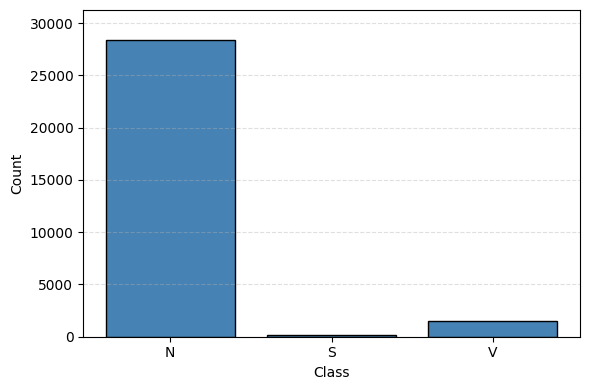

In [99]:
counts = Counter(list(chain.from_iterable(labels_ls)))
categories = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(6, 4))
plt.bar(categories, values, color='steelblue', edgecolor='black')

plt.xlabel('Class')
plt.ylabel('Count')
plt.ylim(0, max(values) * 1.1)  # leave some headroom
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [100]:
print(f"N: {round(values[0]/np.sum(values)*100,2)} %, S: {round(values[1]/np.sum(values)*100,2)} %, V: {round(values[2]/np.sum(values)*100,2)} %")

N: 94.2 %, S: 0.68 %, V: 5.12 %


- A clear skewness toward the normal beats (N) can be observed. Only a few beats are ventricular ectopic (V) and even less are supraventricular ectopic (S).
- This will probably affect the training process of the models, causing the predictions on Normal beats to be more accurate than predictions on V and S-type beats. 

In order to **extract the features** of each beat, in some cases we need to treat the first beats differently. Namely, this is what we are going to do for the features that use previous beats in their computation:
- **RR_current**: it is the time difference between the current and previous beat. For the first beat, since there are no previous beats, we set RR_current to 0, as if there was no difference at all.
- **RR_prev**: it is the time difference between the previous beat and the beat before that. For the first 2 beats, we set RR_prev to 0.
- **RR_local_mean** = it is the mean of the 4 previous intervals to the current beat. The time until the first beat is not considered in the mean computation, since it is often cut. Thus, the local mean is set to 0 for the first beat only. For the following beats until the 4th, we compute the mean with the available intervals in each iteration.

In [101]:
## Feature extraction
rr_current_ls = []
rr_prev_ls = []
rr_ratio_ls = []
rr_local_mean_ls = []
r_amplitude_ls = []
qrs_duration_ls = []
qrs_energy_ls = []
st_mean_ls = []

for l, indiv_pos_ls in enumerate(peaks_pos_ls):
    rr_current = []
    rr_prev = []
    rr_ratio = []
    rr_local_mean = []
    r_amplitude = []
    qrs_duration = []
    qrs_energy = []
    st_mean = []
    for i, pos in enumerate(indiv_pos_ls): 
        if i == 0:
            rr_current.append(0)
            rr_prev.append(0)
            rr_local_mean.append(0)
            rr_ratio.append(1)
        elif i == 1:
            rr_current.append((indiv_pos_ls[1]-indiv_pos_ls[0])/360*1000)
            rr_prev.append(0)
            rr_local_mean.append((indiv_pos_ls[1]-indiv_pos_ls[0])/360*1000)
            rr_ratio.append(1)
        elif i < 5:
            rr_current_val = (indiv_pos_ls[i]-indiv_pos_ls[i-1])/360*1000
            rr_current.append(rr_current_val)
            rr_prev.append((indiv_pos_ls[i-1]-indiv_pos_ls[i-2])/360*1000)
            intervals = []
            intervals.extend([indiv_pos_ls[2+x]-indiv_pos_ls[2+x-1] for x in range(len(indiv_pos_ls[2:i+1]))])
            local_mean = np.mean(intervals)/360*1000
            rr_local_mean.append(local_mean)
            rr_ratio.append(rr_current_val/local_mean)
        else:
            rr_current_val = (indiv_pos_ls[i]-indiv_pos_ls[i-1])/360*1000
            rr_current.append(rr_current_val)
            rr_prev.append((indiv_pos_ls[i-1]-indiv_pos_ls[i-2])/360*1000)
            intervals = []
            intervals.extend([indiv_pos_ls[i-4+x]-indiv_pos_ls[x-1] for x in range(len(indiv_pos_ls[i-4:i+1]))])
            local_mean = np.mean(intervals)/360*1000
            rr_local_mean.append(local_mean)
            rr_ratio.append(rr_current_val/local_mean)
        
        r_amplitude.append(np.mean(signal_ls[l][pos-5:pos+6]))

        half_amp_pre = pos
        half_amp_pos = pos
        while signal_ls[l][half_amp_pre] >= 0.5 * signal_ls[l][pos]:
            half_amp_pre -= 1
        while signal_ls[l][half_amp_pos] >= 0.5 * signal_ls[l][pos]:
            half_amp_pos += 1
        qrs_duration.append(half_amp_pos-half_amp_pre)

        qrs_energy_val = 0
        for x in signal_ls[l][pos-20:pos+21]:
            qrs_energy_val += x**2
        qrs_energy.append(qrs_energy_val)

        st_mean.append(np.mean(signal_ls[l][pos+40:pos+121]))
    
    rr_current_ls.append(rr_current)
    rr_prev_ls.append(rr_prev)
    rr_ratio_ls.append(rr_ratio)
    rr_local_mean_ls.append(rr_local_mean)
    r_amplitude_ls.append(r_amplitude)
    qrs_duration_ls.append(qrs_duration)
    qrs_energy_ls.append(qrs_energy)
    st_mean_ls.append(st_mean)

C:\Users\ipere\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ipere\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [102]:
feature_df=pd.DataFrame()
feature_df["record_id"]=id_ls
feature_df["RR_current"] = rr_current_ls
feature_df["RR_prev"] = rr_prev_ls
feature_df["RR_ratio"] = rr_ratio_ls
feature_df["RR_local_mean"] = rr_local_mean_ls
feature_df["R_amplitude"] = r_amplitude_ls
feature_df["QRS_duration"] = qrs_duration_ls
feature_df["QRS_energy"] = qrs_energy_ls
feature_df["ST_mean"] = st_mean_ls
feature_df["target"] = labels_ls

In [103]:
# Flatten the lists into a one-value-per-cell dataframe
feature_df = (
    feature_df.explode(["RR_current", "RR_prev", "RR_ratio", "RR_local_mean", "R_amplitude", "QRS_duration", "QRS_energy", "ST_mean", "target"], 
                       ignore_index=True)
)

In [104]:
feature_df

,record_id,RR_current,RR_prev,RR_ratio,RR_local_mean,R_amplitude,QRS_duration,QRS_energy,ST_mean,target
0,100,0,0,1,0,0.326364,6,6.79495,-0.342469,N
1,100,813.888889,0,1,813.888889,0.495455,8,8.9521,-0.409691,N
2,100,811.111111,813.888889,1.0,811.111111,0.347727,6,9.1483,-0.39358,N
3,100,788.888889,811.111111,0.986111,800.0,0.307727,6,9.5219,-0.364815,N
4,100,791.666667,788.888889,0.993031,797.222222,0.25,6,8.0761,-0.403025,N
...,...,...,...,...,...,...,...,...,...,...
30157,219,813.888889,747.222222,0.000566,1437660.555556,1.532727,13,29.406025,-0.486173,N
30158,219,405.555556,813.888889,0.000282,1438437.222222,1.376364,13,33.5462,-0.761358,V
30159,219,938.888889,405.555556,0.000652,1439156.111111,0.975,11,33.936025,-1.441481,N
30160,219,761.111111,938.888889,0.000529,1439889.444444,1.118182,11,29.501425,-0.948272,N


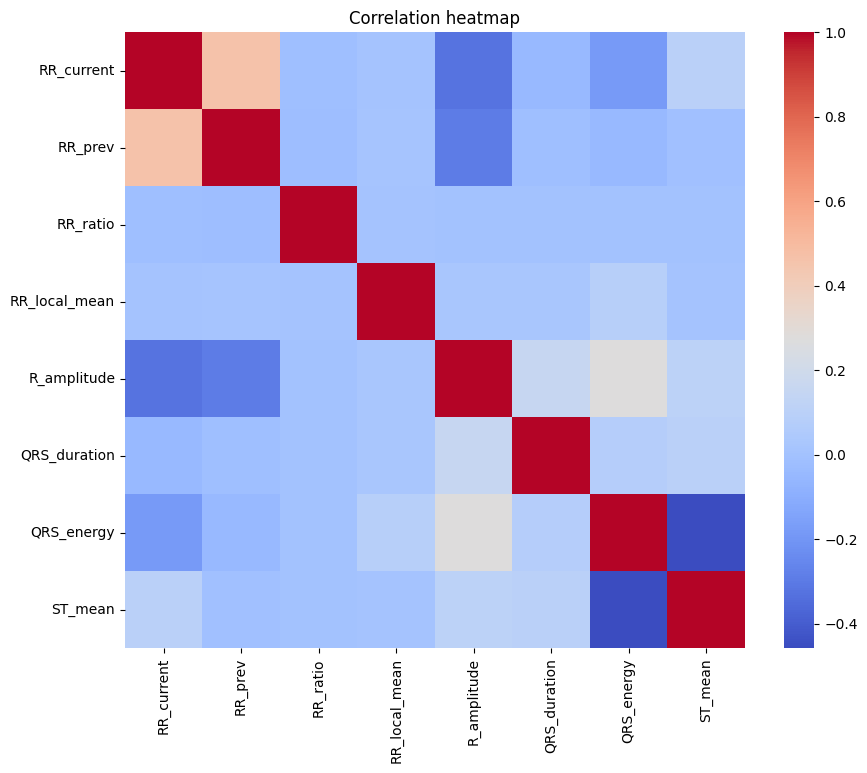

Top correlated pairs:
RR_current     RR_prev          0.461924
R_amplitude    QRS_energy       0.275690
               QRS_duration     0.154625
               ST_mean          0.108094
RR_current     ST_mean          0.098501
QRS_duration   ST_mean          0.095917
RR_local_mean  QRS_energy       0.084834
QRS_duration   QRS_energy       0.073854
RR_local_mean  R_amplitude      0.025076
               QRS_duration     0.023683
RR_prev        RR_local_mean    0.009492
RR_current     RR_local_mean    0.007790
RR_local_mean  ST_mean          0.006692
RR_ratio       RR_local_mean    0.003802
               R_amplitude      0.002045
               QRS_energy       0.001310
               ST_mean          0.000633
               QRS_duration    -0.000701
RR_prev        ST_mean         -0.013155
RR_current     RR_ratio        -0.015064
dtype: float64


In [105]:
plt.figure(figsize=(10, 8))
corr_matrix = feature_df.drop(['record_id', 'target'], axis=1).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()

# Find the most correlated pairs of features
pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))
print("Top correlated pairs:")
print(pairs.head(20))

- RR_current and RR_prev are highly correlated feautres. It makes sense as beat intervals should not vary much from one beat to the next.
- R_amplitude has some (weak) correlation with QRS_energy, since the latter is a sum of R_amplitude with the surrounding amplitudes.

Standard scaling is performed on all 8 features and data split into 80 % train and 20% test sets. 

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [107]:
X = feature_df.drop(columns=['record_id', 'target'])
y = feature_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [108]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # We fit the scaler only on the training set to avoid data leakage
X_test_scaled = scaler.transform(X_test) # We transform the test data using the fitted scaler
# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,RR_current,RR_prev,RR_ratio,RR_local_mean,R_amplitude,QRS_duration,QRS_energy,ST_mean
0,-4.434767,-4.412011,5.949294,-0.994290,-0.282877,-0.107088,-0.855337,0.263949
1,-0.225560,-4.412011,5.949294,-0.992734,-0.053301,-0.039020,-0.739518,0.077784
2,-0.239926,-0.222196,5.949294,-0.992739,-0.253871,-0.107088,-0.728983,0.122402
3,-0.354853,-0.236496,5.866623,-0.992760,-0.308180,-0.107088,-0.708925,0.202065
4,-0.340488,-0.350894,5.907814,-0.992766,-0.386556,-0.107088,-0.786551,0.096247


The class proportions are preserved in train and test datasets:

In [109]:
# We check the distribution of classes in the training and test sets
print(f"Train: {len(X_train)} (Normal: {sum(y_train=="N")}, Supraventricular ectopic: {sum(y_train=="S")}, Ventricular ectopic: {sum(y_train=="V")})")
print(f"In percentages, Normal: {round(sum(y_train=="N")/len(X_train)*100, 2)} %; Supraventricular ectopic: {round(sum(y_train=="S")/len(X_train)*100, 2)} %; Ventricular ectopic: {round(sum(y_train=="V")/len(X_train)*100, 2)} %")
print(f"Test: {len(X_test)} (Normal: {sum(y_test=="N")}, Supraventricular ectopic: {sum(y_test=="S")}, Ventricular ectopic: {sum(y_test=="V")})")
print(f"In percentages, Normal: {round(sum(y_test=="N")/len(X_test)*100, 2)} %; Supraventricular ectopic: {round(sum(y_test=="S")/len(X_test)*100, 2)} %; Ventricular ectopic: {round(sum(y_test=="V")/len(X_test)*100, 2)} %")

Train: 24129 (Normal: 22922, Supraventricular ectopic: 71, Ventricular ectopic: 1136)
In percentages, Normal: 95.0 %; Supraventricular ectopic: 0.29 %; Ventricular ectopic: 4.71 %
Test: 6033 (Normal: 5490, Supraventricular ectopic: 135, Ventricular ectopic: 408)
In percentages, Normal: 91.0 %; Supraventricular ectopic: 2.24 %; Ventricular ectopic: 6.76 %


**Construction of sliding window dataset for RNN and LSTM models**

Create a dataset with consecutive vectors of 10 beats accross the 8 features (10 x 8)

In [110]:
Xw, yw = [], []
window = 10
X = feature_df.drop(columns=['record_id', 'target'])
y = feature_df['target']

for i in range(window - 1, len(X)):
    Xw.append(X[i - window + 1:i + 1])  # beats i-9 through i
    yw.append(y[i])                     # label of beat i

X_seq = np.array(Xw)
y_seq = np.array(yw)

In [111]:
X_seq

array([[[0, 0, 1, ..., np.int64(6), np.float64(6.794950000000001),
         np.float64(-0.3424691358024692)],
        [np.float64(813.8888888888889), 0, 1, ..., np.int64(8),
         np.float64(8.952099999999996),
         np.float64(-0.40969135802469137)],
        [np.float64(811.1111111111111), np.float64(813.8888888888889),
         np.float64(1.0), ..., np.int64(6), np.float64(9.1483),
         np.float64(-0.39358024691358023)],
        ...,
        [np.float64(652.7777777777778), np.float64(816.6666666666666),
         np.float64(-0.0018231158679350384), ..., np.int64(6),
         np.float64(8.572750000000001),
         np.float64(-0.38888888888888884)],
        [np.float64(994.4444444444445), np.float64(652.7777777777778),
         np.float64(-0.0027836310056061396), ..., np.int64(7),
         np.float64(9.512075000000001), np.float64(-0.4432716049382716)],
        [np.float64(844.4444444444445), np.float64(994.4444444444445),
         np.float64(-0.0023691880854778123), ..., np.

In [112]:
y_seq

array(['N', 'N', 'N', ..., 'N', 'N', 'N'], shape=(30153,), dtype='<U1')

Apply again 80/20 split:

In [113]:
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    random_state=42,
    shuffle=False
)